# Retail Sales Analysis

Analysis of retail sales data from MySklad.

In [690]:
import pandas as pd 
import requests as rq
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations 
from collections import Counter

In [691]:
pd.set_option('display.max_columns' , 40)

СОЗДАЕМ ДАННЫЕ ДЛЯ ЗАПРОСА В УЧЕТНУЮ ПРОГРАММУ "МОЙ СКЛАД"

In [714]:
# API-токен
TOKEN = 'Токен'

# Параметр headers
headers = {
    'Authorization':f'Bearer {TOKEN}'
}

# Параметр params 

params = {
    'filter': 'moment>=2026-07-25 00:00:00;moment<=2026-08-25 23:59:59'
}

# Берем ссылку из документации для получения чеков от продаж

url = 'https://api.moysklad.ru/api/remap/1.2/entity/retaildemand'

ОТПРАВЛЯЕМ ЗАПРОС И ПОЛУЧАЕМ ОТВЕТ ОТ "МОЙ СКЛАД"

In [715]:
respons = rq.get(
    url,
    headers = headers,
    params = params
)

if respons.status_code == 200:
    print('Запрос составлен успешно')

Запрос составлен успешно


In [716]:
# Записывает полученный ответ в переменную data и преобразуем  json

data = respons.json()

In [717]:
# Полученный ответ хранится в виде словаря
type(data)

dict

In [718]:
data.keys()

dict_keys(['context', 'meta', 'rows'])

СОЗДАЕМ ПЕРЕМЕННУЮ С ТАБЛИЦЕЙ О ВСЕХ ЧЕКАХ

In [719]:
# Передаем сюда список чеков из полученного ответа
df_sales = pd.json_normalize(data['rows'])

In [720]:
df_sales.shape

(1000, 87)

In [721]:
df_sales.columns

Index(['id', 'accountId', 'shared', 'updated', 'name', 'externalCode',
       'syncId', 'moment', 'applicable', 'sum', 'created', 'printed',
       'published', 'vatEnabled', 'vatIncluded', 'vatSum', 'payedSum',
       'fiscal', 'cashSum', 'noCashSum', 'qrSum', 'prepaymentCashSum',
       'prepaymentNoCashSum', 'prepaymentQrSum', 'advancePaymentSum',
       'taxSystem', 'meta.href', 'meta.metadataHref', 'meta.type',
       'meta.mediaType', 'meta.uuidHref', 'owner.meta.href',
       'owner.meta.metadataHref', 'owner.meta.type', 'owner.meta.mediaType',
       'owner.meta.uuidHref', 'group.meta.href', 'group.meta.metadataHref',
       'group.meta.type', 'group.meta.mediaType', 'rate.currency.meta.href',
       'rate.currency.meta.metadataHref', 'rate.currency.meta.type',
       'rate.currency.meta.mediaType', 'rate.currency.meta.uuidHref',
       'store.meta.href', 'store.meta.metadataHref', 'store.meta.type',
       'store.meta.mediaType', 'store.meta.uuidHref', 'agent.meta.href',
     

In [722]:
df_sales.sort_values('moment')

,id,accountId,shared,updated,name,externalCode,syncId,moment,applicable,sum,created,printed,published,vatEnabled,vatIncluded,vatSum,payedSum,fiscal,cashSum,noCashSum,...,positions.meta.type,positions.meta.mediaType,positions.meta.size,positions.meta.limit,positions.meta.offset,retailStore.meta.href,retailStore.meta.metadataHref,retailStore.meta.type,retailStore.meta.mediaType,retailStore.meta.uuidHref,retailShift.meta.href,retailShift.meta.metadataHref,retailShift.meta.type,retailShift.meta.mediaType,retailShift.meta.uuidHref,cheque.fnNumber,cheque.fiscalDocSign,cheque.fiscalDocNumber,cheque.time,returns
445,5851f7c9-87eb-11f1-0a80-1c9b001cf4df,ecb92972-4a20-11f1-0a80-0bbb00008359,False,2026-07-25 08:40:29.313,00012,tsR0RnNNgbF1xJOL-LA2B2,c1121684-7cb7-44b1-9c29-1fdf08cbb8a9,2026-07-25 08:40:00.000,True,18000.0,2026-07-25 08:40:29.389,False,False,True,True,0.0,0.0,False,18000.0,0.0,...,demandposition,application/json,2,1000,0,https://api.moysklad.ru/api/remap/1.2/entity/r...,https://api.moysklad.ru/api/remap/1.2/entity/r...,retailstore,application/json,https://online.moysklad.ru/app/#retailstore/ed...,https://api.moysklad.ru/api/remap/1.2/entity/r...,https://api.moysklad.ru/api/remap/1.2/entity/r...,retailshift,application/json,https://online.moysklad.ru/app/#retailshift/ed...,7380440903728355,2710317692,35,2026-07-25 08:39:00.000,NaN
911,c3225786-87fa-11f1-0a80-1064001b3b1d,ecb92972-4a20-11f1-0a80-0bbb00008359,False,2026-07-25 10:30:50.955,00014,X84nqUq8iJwwoByJF4D9r0,182402c4-8759-4b61-8920-dadd817acd85,2026-07-25 10:30:00.000,True,207270.0,2026-07-25 10:30:51.049,False,False,True,True,0.0,0.0,False,0.0,207270.0,...,demandposition,application/json,4,1000,0,https://api.moysklad.ru/api/remap/1.2/entity/r...,https://api.moysklad.ru/api/remap/1.2/entity/r...,retailstore,application/json,https://online.moysklad.ru/app/#retailstore/ed...,https://api.moysklad.ru/api/remap/1.2/entity/r...,https://api.moysklad.ru/api/remap/1.2/entity/r...,retailshift,application/json,https://online.moysklad.ru/app/#retailshift/ed...,7380440903728355,0382166379,37,2026-07-25 10:29:00.000,NaN
569,77f9c54b-87fc-11f1-0a80-1064001b7b1f,ecb92972-4a20-11f1-0a80-0bbb00008359,False,2026-07-25 10:43:03.902,00015,Zcva11vOhUfs6hk3DhvhJ2,a8d6c299-d4c5-4822-89f2-66b0b01cad5a,2026-07-25 10:42:00.000,True,2000.0,2026-07-25 10:43:03.949,False,False,True,True,0.0,0.0,False,0.0,2000.0,...,demandposition,application/json,1,1000,0,https://api.moysklad.ru/api/remap/1.2/entity/r...,https://api.moysklad.ru/api/remap/1.2/entity/r...,retailstore,application/json,https://online.moysklad.ru/app/#retailstore/ed...,https://api.moysklad.ru/api/remap/1.2/entity/r...,https://api.moysklad.ru/api/remap/1.2/entity/r...,retailshift,application/json,https://online.moysklad.ru/app/#retailshift/ed...,7380440903728355,1325622531,38,2026-07-25 10:41:00.000,NaN
761,a36f6d52-87fc-11f1-0a80-1064001b8124,ecb92972-4a20-11f1-0a80-0bbb00008359,False,2026-07-25 10:44:16.812,00016,T8tE--vvjzqHJkuPA22Vi2,8ba3e534-18b5-4c79-8eb5-1b3997c47b70,2026-07-25 10:44:00.000,True,11300.0,2026-07-25 10:44:16.861,False,False,True,True,0.0,0.0,False,0.0,11300.0,...,demandposition,application/json,1,1000,0,https://api.moysklad.ru/api/remap/1.2/entity/r...,https://api.moysklad.ru/api/remap/1.2/entity/r...,retailstore,application/json,https://online.moysklad.ru/app/#retailstore/ed...,https://api.moysklad.ru/api/remap/1.2/entity/r...,https://api.moysklad.ru/api/remap/1.2/entity/r...,retailshift,application/json,https://online.moysklad.ru/app/#retailshift/ed...,7380440903728355,1739166762,39,2026-07-25 10:42:00.000,NaN
149,1fe37960-8807-11f1-0a80-0e0200202f76,ecb92972-4a20-11f1-0a80-0bbb00008359,False,2026-07-25 11:59:20.563,00017,f-ncvU1ViKB3Gx7hmd8EH2,23aac236-0843-4040-9070-58518e5f9ff4,2026-07-25 11:59:00.000,True,52000.0,2026-07-25 11:59:20.622,False,False,True,True,0.0,0.0,False,52000.0,0.0,...,demandposition,application/json,3,1000,0,https://api.moysklad.ru/api/remap/1.2/entity/r...,https://api.moysklad.ru/api/re

In [723]:
#Делаем индексы удабными для дальнейшего сбора таблицы с позициями и правильными датами по порядку
df_sales = df_sales.sort_values('moment').reset_index(drop=True)

In [724]:
# Нам нужны позиции в чеке. Из документации мы знаем что информация о позициях находится по ссылкам в столбце 'positions.meta.href'
# Отправляем запросы по этим ссылкам чтобы достать проданные позиции из всех чеков и собираем из этих данных таблицу для анализа

БЕРЕМ ДАННЫЕ ИЗ ОТЧЕТА О ПРИБОЛЬНОСТИ ДЛЯ ПОЛУЧЕНИЯ СЕБЕСТОИМОСТИ ТОВАРОВ

In [980]:
url2 = 'https://api.moysklad.ru/api/remap/1.2/report/profit/byproduct'+'?expand=assortment'

respons = rq.get(
    url2, headers = headers
)

data_prof = respons.json()

df_profit = pd.json_normalize(data_prof['rows'])

df_profit = df_profit[
    ['sellQuantity',
     'sellPrice', 
     'sellCost', 
     'sellSum',
     'assortment.name',
     'assortment.code']
    ]

new_columns = [
    'quanity',
    'price',
    'cost_price',
    'sellSum',
    'name',
    'code'
]

df_profit.columns = new_columns

df_profit['cost_price'] = df_profit['cost_price']/100
df_profit['price'] = df_profit['price'] / 100

ДОБАВЛЯЕМ СЕБЕСТОИМОСТЬ НЕКОТОРЫХ ТОВАРОВ

In [137]:
df_profit[df_profit['cost_price']==0]

,quanity,price,cost_price,sellSum,name,code
33,5.946,689.000000,0.0,409679.4,Аджапсандали,5998304241203
37,3.444,970.000000,0.0,334068.0,Баранина лопатка,00035
38,2.064,1250.000000,0.0,258000.0,Баранина мякоть,00038
39,1.338,1449.000000,0.0,193876.2,Баранина мякоть шашлык,5998304241164
40,6.778,1400.000000,0.0,948920.0,Баранина пистолетики,5998304241173
...,...,...,...,...,...,...
236,1.358,315.000000,0.0,42777.0,Чебурек с мясом,LIDER57-006
237,109.000,300.000000,0.0,3270000.0,Шашлык в лаваше,5998304241188
238,97.000,280.000000,0.0,2716000.0,Шашлык в лаваше куриный,5998304241190
239,11.620,886.792427,0.0,1030452.8,Шашлык терияки,5998304241191


In [24]:
df_sebest = pd.DataFrame({'Наименование': ["Свинина", "Говядина", "Баранина",'Курицы.Филе','Курица.Окорочка','Курица.Крыло', 'Курица.Бедро', 'Курица.Голень'],
                          'В закупе': [288,510,600,375,275,270,140,135],
                          "Отходы %": [35,35,10,0,0,0,0,0],
                          'Примерная себестоимость' : [440,710,667,375,275,270,270,270]})

df_sebest


,Наименование,В закупе,Отходы %,Примерная себестоимость
0,Свинина,288,35,440
1,Говядина,510,35,710
2,Баранина,600,10,667
3,Курицы.Филе,375,0,375
4,Курица.Окорочка,275,0,275
5,Курица.Крыло,270,0,270
6,Курица.Бедро,140,0,270
7,Курица.Голень,135,0,270


In [138]:
# Примераня себестоимость свинины , записываем в df_profit, потому что оттуда мы бужем подтягивать ее
mask_svin = (df_profit['name'].str.contains('сви', case = False, na = False)
        & (df_profit['price'] > 439)& (df_profit['cost_price'] == 0))
      

In [139]:
df_profit.loc[mask_svin, 'cost_price'] = 440


In [140]:
df_profit[df_profit['name'].str.contains('сви', case = False, na = False)]

,quanity,price,cost_price,sellSum,name,code
56,3.000,550.000000,440.0,165000.0,Вырезка свиная,00024
81,0.780,720.000000,440.0,56160.0,"""Домашний Шеф"" Пельмени свино-говядина",00020
90,0.546,980.000000,440.0,53508.0,Котлеты свино-говяжие,00186
115,47.000,229.148936,0.0,1077000.0,Люля свин/говяж,5998304241158
183,1.872,220.000000,0.0,41184.0,Рулька свиная,5998304241195
184,2.000,220.000000,0.0,44000.0,Рульки свиные,00015
186,11.638,440.000000,440.0,512072.0,Свинина антрекот,00120
187,8.230,649.496476,440.0,534535.6,Свинина антрекот маринов.,5998304241153
188,10.691,649.273127,440.0,694137.9,Свинина антрекот Маринов.,5998304241177
189,8.070,490.000000,440.0,395430.0,Свинина лопатка без кости,00122


In [141]:
# Примерная себестоимость говядины
mask_gov = (df_profit['name'].str.contains('гов', case = False, na = False) &
       (df_profit['price'] > 700) & (df_profit['cost_price'] == 0))

In [142]:
df_profit.loc[mask_gov,'cost_price'] = 710

In [143]:
# Примерная себестоимость баранины
mask_bar = (df_profit['name'].str.contains('бар', case = False, na = False) &
       (df_profit['price'] > 670) 
            & (df_profit['cost_price'] == 0))

In [144]:
df_profit.loc[mask_bar, 'cost_price'] = 670

In [165]:
# Себестоимость разных видов курицы
mask_kur = df_profit['name'].str.contains('кур', case = False, na = False) & (df_profit['cost_price'] == 0)

mask_kur1 = (df_profit['name'].str.contains('курица', case = False, na = False) & (df_profit['cost_price'] == 0))     

In [727]:
df_profit

,quanity,price,cost_price,sellSum,name,code
0,19.000,145.000000,134.9,275500.0,"0,25Л ЭНЕРГ НАПИТОК RED BULL TROPICAL Ж/Б3",219117
1,20.000,145.000000,134.9,290000.0,"0,25Л ЭНЕРГ НАПИТОК RED BULL Ж/Б",357755
2,1.000,155.000000,145.0,15500.0,100Г КОФЕ LEBO EXTRA ДЛЯ ТУРКИ МОЛОТЫЙ,125675
3,1.000,71.000000,59.9,7100.0,1КГ МУКА УВЕЛКА ПШЕНИЧНАЯ ХЛЕБОПЕКАРНАЯ В/С,335299
4,3.000,180.000000,149.0,54000.0,1Л МАСЛО ПОДСОЛНЕЧНОЕ ОЛЕЙНА,146992
...,...,...,...,...,...,...
270,136.000,300.000000,0.0,4080000.0,Шашлык в лаваше,5998304241188
271,129.000,280.000000,0.0,3612000.0,Шашлык в лаваше куриный,5998304241190
272,14.968,878.339123,0.0,1314698.0,Шашлык терияки,5998304241191
273,1.000,0.000000,0.0,0.0,Шея свиная,00025


In [168]:
df_profit[mask_kur1] 

,quanity,price,cost_price,sellSum,name,code
93,13.398,800.000000,275.0,1071840.0,Курица ассорти шашлык,5998304241184
94,1.352,400.000000,275.0,54080.0,Курица бедро домашние,00149
95,7.544,350.000000,275.0,264040.0,Курица бедро фермерское,00155
96,35.372,557.560387,275.0,1972202.6,Курица в ассортменте маринов.,5998304241155
97,5.128,350.000000,275.0,179480.0,Курица голень,00150
98,4.228,381.880322,275.0,161459.0,Курица голень домашние,5998304241113
99,12.588,341.440261,275.0,429805.0,Курица крыло,00159
100,1.102,370.000000,275.0,40774.0,Курица крылья домашние,00148
101,2.762,800.000000,275.0,220960.0,Курица крылья шашлык,5998304241187
102,4.140,410.000000,275.0,169740.0,Курица окорочка домашние,00151


In [167]:
df_profit.loc[mask_kur1, 'cost_price'] = 275

In [170]:
#Оставшиеся товары в среднем продаются на 30% дороже себестоимости (информация от заказчика)

mask_ost = df_profit['cost_price'] == 0
df_profit.loc[mask_ost, 'cost_price'] = df_profit['price']/ 1.3

In [735]:
df_profit

,code,cost_price
0,5998304241120,0.769231
1,4607093920107,53.290000
2,4860019001346,116.610000
3,4603334001529,48.550000
4,ЦБ-00015831,62.322000
...,...,...
1730,3083680048774,105.740000
1748,00036,670.000000
1753,4860019003114,105.590000
1836,4605246016448,262.340000


In [736]:
df_profit.columns

Index(['code', 'cost_price'], dtype='str')

РАСПАКОВКА ЧЕКОВ С СОЗДАНИЕМ ТАБЛИЦЫ, СОДЕРЖАЩЕЙ КАЖДЫЙ ПРОДАНННАЙ ТОВАР ИЗ ЧЕКА(ПО ПОЗИЦИЯМИ ЧЕКА)

In [781]:
#СОЗДАЕМ ПУСТОЙ ДАТАФРЕЙМ, КУДА БУДЕМ СГРУЖАТЬ НОВЫЕ ПОЗИЦИИ
df_sales_positions = pd.DataFrame()

In [799]:
def take_positions (end):
    global df_sales_positions
    
    all_positions = []
    #start. Первый запуск
    if 'order_id' in df_sales_positions.columns : 
        start = df_sales_positions.nunique()['order_id'] # Опытным путем было установлено оптимальное к-во загрузки чеков - 100 штук, поэтому ограничение 100шт за раз
    else : 
        start = 0
    end = start +  end  
    for i, url in df_sales['positions.meta.href'].iloc[start : end].items(): # Создаем кортеж с номером итерации для подгрузки даты/id из таблицы о чеках
        respons = rq.get(url + '?expand=assortment' ,        # Из документации берем часть ссылки, которая напрямую будет давать позиции в чеке 
                     headers = headers)  
        data_pos = respons.json()

        df_position = pd.json_normalize(data_pos['rows'])       # Создаем DataFrame из позиции текущего чека 
        
        df_position = df_position[                      # Берем только нужные столбцы 
        [ 
            'assortment.name',
            'assortment.code',
            'quantity',
            'price',
            'discount'  
        ]
    ]
 
        df_position.columns = [                      # Переименовываем
        
        'name',
        'code',
        'quantity',
        'price',
        'discount'
    ]

        df_position['dt'] = df_sales.loc[i, 'moment']   # Добавляем дату из таблицы чеков, так как в ссылке на позиции находятся карточки товаров 
                                                     # В этой таблице нет даты продажи
    
        df_position['order_id'] = df_sales.loc[i, 'id'] # Добавляем id заказа из таблицы чеков
    
        df_position['price'] /= 100           # Информация о ценах отображает в копейках , переводим в рубли

        df_position['revenue'] = (
        df_position['quantity'] *
        df_position['price']
    )

        all_positions.append(df_position)   # Добавляем DataFrame в список , собираем таблицу по проданным позициям

    df_new_positions = pd.concat(all_positions, ignore_index = True) # Получаем таблицу состоящую из проданных товаров

    df_new_positions= df_new_positions.merge(        #СОЕДИНЯЕМ ТАБЛИЦУ С ПРОДАЖАМИ С ТАБЛИЦЕЙ ПРИБОЛЬНОСТИ , ОТКУДА ВОЗЬМЕМ СЕБЕСТОИМОСТЬ
    df_profit[['code', 'cost_price']],
    left_on = 'code',
    right_on = 'code',
    how = 'left'
)
    
    print (f'Последний загруженный чек № {i+1}')      
    
    df_sales_positions = pd.concat([ df_sales_positions, df_new_positions], ignore_index=True)
    
                                                                

In [809]:
#Автоматизируем загрузку новых чеков
n = int(input('Сколько новых чеков загрузить?'))
take_positions (n)


Сколько новых чеков загрузить? 0


ValueError: No objects to concatenate

In [806]:
len(df_sales)

1000

In [807]:
df_sales_positions.shape

(2038, 9)

СОХРАНЯЕМ ДАТАСЕТ ДЛЯ ДАЛЬНЕЙШЕЙ РАБОТЫ

In [810]:
df_sales_positions.to_csv(
    'sales_dataset_.csv',
    index=False,
    encoding='utf-8-sig'
)

In [814]:
df_sales_positions = df_sales_positions[['order_id', 'name', 'code', 'quantity', 'price','cost_price', 'discount', 'dt', 'revenue']]

In [813]:
# Присваиваем удобной переменной, так как будем работать дальше с ней, в основном
df = df_sales_positions

In [815]:
df

,order_id,name,code,quantity,price,cost_price,discount,dt,revenue
0,5851f7c9-87eb-11f1-0a80-1c9b001cf4df,Мороженое пломбир шоколадный,L56-002,1.000,90.0,67.100000,0.0,2026-07-25 08:40:00.000,90.0
1,5851f7c9-87eb-11f1-0a80-1c9b001cf4df,Мороженое пломбир ванильный с шоколадной крошкой,L56-003,1.000,90.0,67.100000,0.0,2026-07-25 08:40:00.000,90.0
2,c3225786-87fa-11f1-0a80-1064001b3b1d,Курица в ассортменте маринов.,5998304241155,1.048,650.0,275.000000,0.0,2026-07-25 10:30:00.000,681.2
3,c3225786-87fa-11f1-0a80-1064001b3b1d,Свинина шея маринов.,5998304241152,1.242,750.0,440.000000,0.0,2026-07-25 10:30:00.000,931.5
4,c3225786-87fa-11f1-0a80-1064001b3b1d,СОУС КУЛИНАРНЫЙ - СОУС АДЖИЧНЫЙ НА КИЗИЛЕ,5998304241134,1.000,230.0,173.996000,0.0,2026-07-25 10:30:00.000,230.0
...,...,...,...,...,...,...,...,...,...
2033,393676fe-9f93-11f1-0a80-1cfb0095c1a9,Шея свиная,00025,1.000,0.0,NaN,0.0,2026-08-24 11:09:00.000,0.0
2034,393676fe-9f93-11f1-0a80-1cfb0095c1a9,Свинина шейная,00125,1.230,680.0,440.000000,0.0,2026-08-24 11:09:00.000,836.4
2035,7bc14b97-9f93-11f1-0a80-1fa10082499d,Шашлык в лаваше,5998304241188,1.000,300.0,230.769231,0.0,2026-08-24 11:11:00.000,300.0
2036,6860e691-9f96-11f1-0a80-1cfb0096e1bf,РИЧ СПРИТЦ КОКТЕЙЛЬ 1.0,ЦБ-00029252,1.000,120.0,90.507500,0.0,2026-08-24 11:32:00.000,120.0


СБОР ДАННЫХ ЗАКОНЧЕН, ПРИСТУПАЕМ К ИССЛЕДОВАНИЮ

In [816]:
df.shape

(2038, 9)

In [1067]:
df.info()

<class 'pandas.DataFrame'>
Index: 2035 entries, 0 to 2037
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   order_id    2035 non-null   str           
 1   name        2035 non-null   str           
 2   code        2035 non-null   str           
 3   quantity    2035 non-null   float64       
 4   price       2035 non-null   float64       
 5   cost_price  2035 non-null   float64       
 6   discount    2035 non-null   float64       
 7   dt          2035 non-null   datetime64[us]
 8   revenue     2035 non-null   float64       
 9   profit      2035 non-null   float64       
 10  margin      2000 non-null   float64       
dtypes: datetime64[us](1), float64(7), str(3)
memory usage: 190.8 KB


In [818]:
df['dt'] =pd.to_datetime(df['dt']) # dt переводим из str в datetime

In [819]:
df.duplicated().sum()

np.int64(0)

In [820]:
df.describe()

,quantity,price,cost_price,discount,dt,revenue
count,2038.000000,2038.000000,2001.000000,2038.000000,2038,2038.000000
mean,1.332826,278.066241,199.239169,0.201726,2026-08-09 14:04:29.028459,342.645505
min,0.044000,0.000000,0.000000,0.000000,2026-07-25 08:40:00,0.000000
25%,1.000000,79.250000,62.322000,0.000000,2026-08-01 18:52:00,90.000000
50%,1.000000,152.500000,134.900000,0.000000,2026-08-09 12:34:00,185.515000
75%,1.239500,440.000000,275.000000,0.000000,2026-08-16 16:20:00,420.679500
max,15.000000,2000.000000,846.153846,99.000000,2026-08-24 11:36:00,5040.000000
std,1.063698,277.423524,184.546254,3.336344,NaN,436.821776


РАСЧИТЫВАЕМ ОСНОВНЫЕ ПОКАЗАТЕЛИ KPI(ПО ПРОДАННЫМ ПОЗИЦИЯМ)

In [822]:
# Общая выручка

total_revenue = df['revenue'].sum()

# Общее колличество проданного товара

total_quantity = df['quantity'].sum()

# Общая себестоимость 

total_cost_price = (df['cost_price']*df['quantity']).sum()

# Валовая прибыль

gross_profit = total_revenue - total_cost_price

# Валовая маржинальность

gross_margin = gross_profit/total_revenue * 100

АНАЛИЗИРУЕМ ЧЕКИ

In [823]:
# Общее к-во чеков
df['order_id'].nunique()

1000

In [827]:
# Средний чек
average_check = df.groupby('order_id')['revenue'].sum().mean()

# Среднее к-во товаров(позиций) в чеке
average_pos_per_check = df.groupby('order_id')['name'].count().mean()

In [828]:
average_pos_per_check 

np.float64(2.038)

ВЫВЕДИМ ТОПЫ ТОВАРОВ

In [842]:
# Топ товаров по выручке
# Какие товары дают больше всего оборота?
top_pos_revenue = df.groupby('name')['revenue'].sum().sort_values(ascending = False).head(10)

top_pos_revenue

name
Шашлык в лаваше                  35400.000
Люля курин.                      34060.000
Шашлык в лаваше куриный          29400.000
Свинина мякоть маринов.          28424.500
Свинина шейка маринов.           24945.000
Курица филе фермерское           24457.790
Свинина шея маринов.             21117.750
Курица в ассортменте маринов.    20536.742
Фарш куриный                     19978.500
Свинина ребра                    17492.640
Name: revenue, dtype: float64

In [1031]:
df['profit'] = df['revenue'] - df['cost_price'] * df['quantity']

In [844]:
# Топ товаров по чистой приыбли
# Какие товары реально зарабатывают деньги?

top_pos_profit = df.groupby('name')['profit'].sum().sort_values(ascending = False).head(10)

top_pos_profit
# Из этого анализа мы видим , что товары генерируемые самые большие продажи, не не всегда являются самыми прибыльным

name
Курица в ассортменте маринов.    10401.342000
Свинина шейка маринов.           10310.600000
Курица терияки маринов.           9240.250000
Свинина мякоть маринов.           9183.300000
Курица ассорти шашлык             9059.400000
Свинина шея маринов.              8728.670000
Свинина мякоть шашлык             8344.566000
Шашлык в лаваше                   8169.230769
Люля курин.                       7204.230769
Свинина ребра шашлык              7015.811000
Name: profit, dtype: float64

In [845]:
# Добавим информацию о маржинальности

df['margin'] = df['profit'] / df['revenue'] * 100

df_margin = df.groupby('name')[['revenue', 'profit']].sum()
df_margin['margin'] = (df_margin['profit'] /df_margin['revenue']) * 100 
top_pos_margin = df_margin.sort_values('margin', ascending = False).head(10)
top_pos_margin = top_pos_margin.reset_index()
top_pos_margin

,name,revenue,profit,margin
0,Курица крылья шашлык,2209.600,1450.050,65.625000
1,Курица ассорти шашлык,13804.800,9059.400,65.625000
2,Вырезка говяжья,2276.000,1468.020,64.500000
3,Свинина шея шашлык,4355.298,2560.978,58.801441
4,Баранина пистолетики шашлык,2008.344,1166.824,58.098812
5,Курица терияки маринов.,16023.400,9240.250,57.667224
6,Котлеты свино-говяжие,1097.600,604.800,55.102041
7,Баранина пистолетики,5205.200,2714.140,52.142857
8,Свинина мякоть шашлык,16004.966,8344.566,52.137355
9,Свинина ребра шашлык,13579.291,7015.811,51.665518


ПРОАНАЛИЗИРУЕМ ВРЕМЕНЫЕ ХАРАКТЕРИСТИКИ

In [867]:
df['dt'].dtype


dtype('<M8[us]')

In [868]:
daily_revenue_profit = (
    df.groupby(df['dt'].dt.date)
      .agg(
          revenue=('revenue', 'sum'),
          profit=('profit', 'sum')
      )
      .reset_index()
)

daily_revenue_profit['dt'] = pd.to_datetime(
    daily_revenue_profit['dt']
)

daily_revenue_profit.sort_values(
    'profit',
    ascending=False
)

,dt,revenue,profit
1,2026-07-26,47398.580,19503.390752
8,2026-08-02,32645.984,10012.871241
21,2026-08-15,34052.376,9565.479812
14,2026-08-08,36525.054,9401.639635
11,2026-08-05,39685.116,9353.315058
15,2026-08-09,35380.468,9157.896659
17,2026-08-11,34169.158,8419.771939
3,2026-07-28,27687.880,8322.764355
29,2026-08-23,29458.498,7759.799593
22,2026-08-16,30244.921,7571.552071


In [870]:
daily_revenue_profit.sort_values('profit', ascending = False)

,dt,revenue,profit
1,2026-07-26,47398.580,19503.390752
8,2026-08-02,32645.984,10012.871241
21,2026-08-15,34052.376,9565.479812
14,2026-08-08,36525.054,9401.639635
11,2026-08-05,39685.116,9353.315058
15,2026-08-09,35380.468,9157.896659
17,2026-08-11,34169.158,8419.771939
3,2026-07-28,27687.880,8322.764355
29,2026-08-23,29458.498,7759.799593
22,2026-08-16,30244.921,7571.552071


In [869]:
daily_revenue_profit.sort_values('revenue', ascending = False)

,dt,revenue,profit
1,2026-07-26,47398.580,19503.390752
11,2026-08-05,39685.116,9353.315058
14,2026-08-08,36525.054,9401.639635
15,2026-08-09,35380.468,9157.896659
17,2026-08-11,34169.158,8419.771939
21,2026-08-15,34052.376,9565.479812
8,2026-08-02,32645.984,10012.871241
22,2026-08-16,30244.921,7571.552071
29,2026-08-23,29458.498,7759.799593
7,2026-08-01,27926.360,6679.192293


СДЕЛАЕМ ГРАФИКИ ПО  ПРИБЫЛИ ПО ДНЯМ

In [871]:
daily_revenue_profit = daily_revenue_profit.sort_values('dt')
daily_revenue_profit

,dt,revenue,profit
0,2026-07-25,14103.760,4548.805117
1,2026-07-26,47398.580,19503.390752
2,2026-07-27,17701.120,3982.039287
3,2026-07-28,27687.880,8322.764355
4,2026-07-29,16153.360,3932.447969
5,2026-07-30,17483.140,4311.164213
6,2026-07-31,19994.200,6105.548873
7,2026-08-01,27926.360,6679.192293
8,2026-08-02,32645.984,10012.871241
9,2026-08-03,9672.382,2614.609747


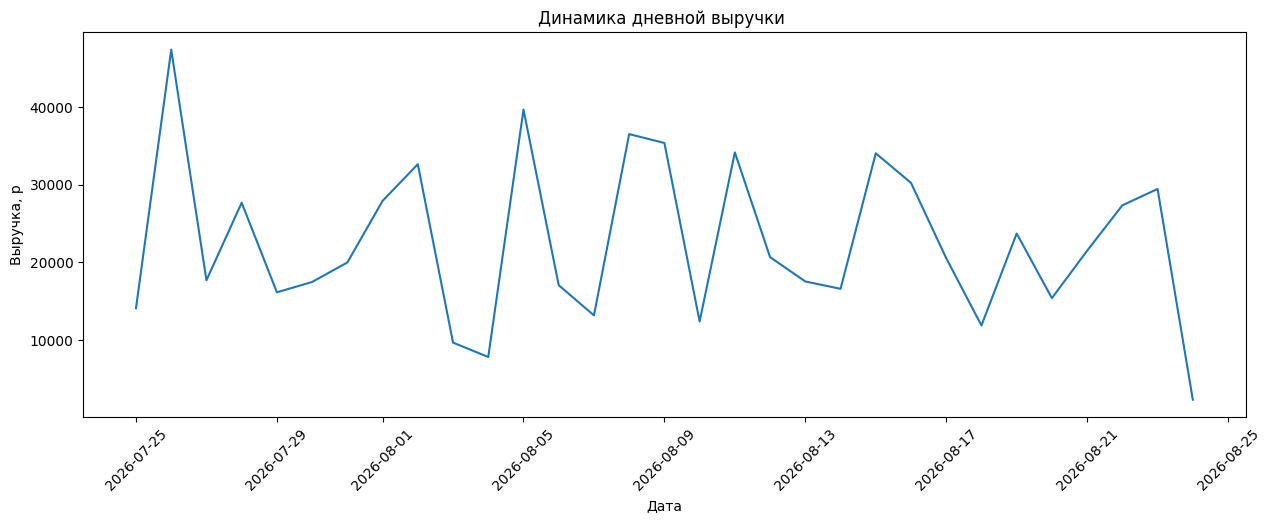

In [872]:
# Создаем график 
x = daily_revenue_profit['dt']
y = daily_revenue_profit['revenue']

plt.figure(figsize= (15,5))

plt.plot(x,y)

plt.xlabel('Дата')
plt.ylabel('Выручка, р')
plt.title('Динамика дневной выручки ')
plt.xticks(rotation = 45)
plt.show()

In [923]:
revenue_day_of_week = df.groupby(df['dt'].dt.dayofweek). agg(
    revenue = ('revenue', 'sum'),
    profit = ('profit', 'sum'),
    c_orders = ('order_id', 'nunique')
    ).reset_index()

In [924]:
revenue_day_of_week

,dt,revenue,profit,c_orders
0,0,62635.638,14851.703958,112
1,1,81561.934,20741.479659,124
2,2,100238.993,24735.279555,119
3,3,67496.665,16570.155049,141
4,4,71286.910,18008.640086,138
5,5,139962.948,36520.333631,199
6,6,175128.451,54005.510316,167


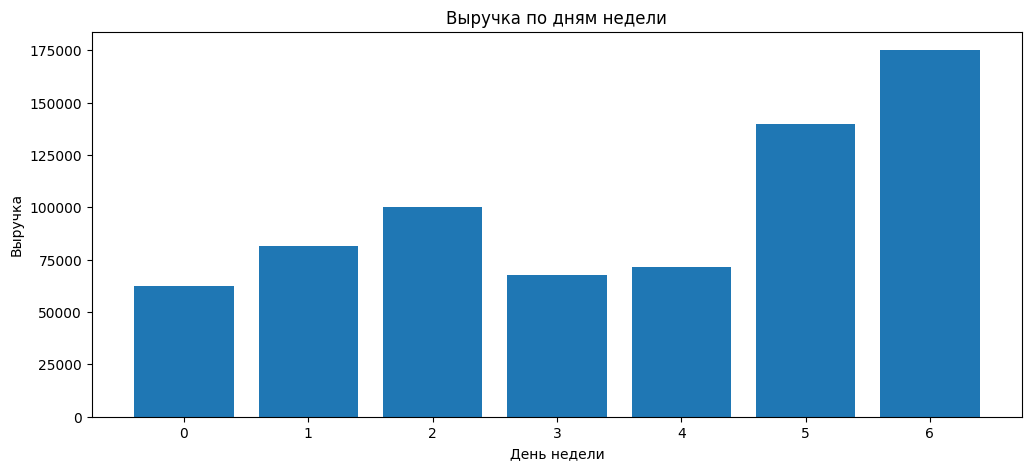

In [925]:
x1 = revenue_day_of_week['dt']
y1 = revenue_day_of_week['revenue']

plt.figure(figsize=(12, 5))

plt.bar(x1, y1)

plt.xlabel('День недели')
plt.ylabel('Выручка')
plt.title('Выручка по дням недели')

plt.show()



In [926]:
revenue_hour_of_day = df.groupby(df['dt'].dt.hour). agg(
    revenue = ('revenue', 'sum'),
    profit = ('profit', 'sum'),
    c_orders = ('order_id', 'nunique')
    ).reset_index()

In [927]:
revenue_hour_of_day

,dt,revenue,profit,c_orders
0,8,4858.000,1436.124154,8
1,9,14856.592,2625.062294,21
2,10,37310.196,10975.309989,54
3,11,89876.691,25714.352848,90
4,12,52262.292,11953.276166,98
5,13,86784.468,22972.949357,95
6,14,60431.564,17280.392591,95
7,15,70848.392,17834.832824,93
8,16,49299.380,13135.261545,74
9,17,72374.111,17901.191326,111


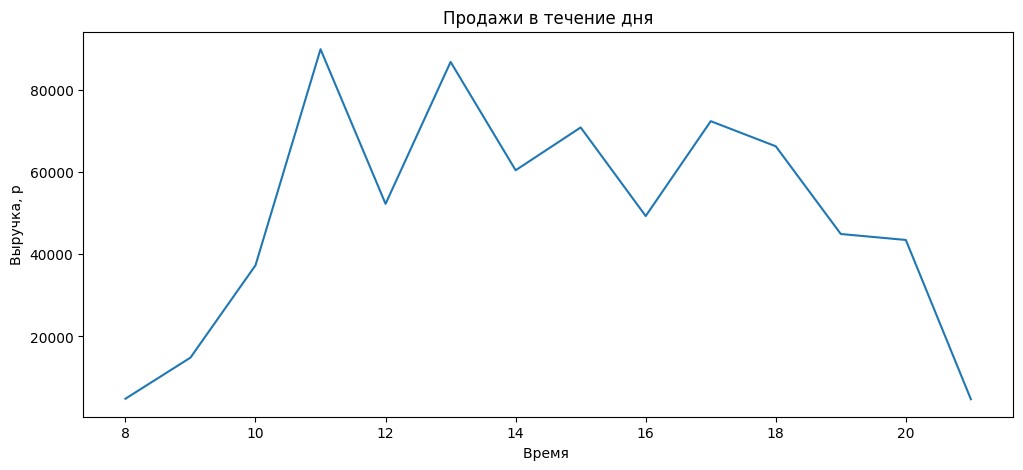

In [930]:
x1 = revenue_hour_of_day['dt']
y1 = revenue_hour_of_day['revenue']

plt.figure(figsize=(12, 5))

plt.plot(x1, y1)

plt.xlabel('Время ')
plt.ylabel('Выручка, р')
plt.title('Продажи в течение дня')

plt.show()


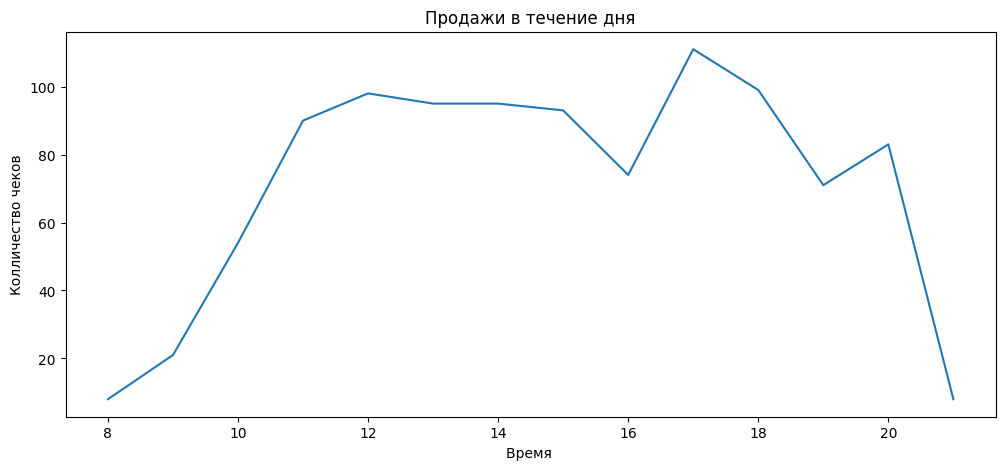

In [932]:
x1 = revenue_hour_of_day['dt']
y1 = revenue_hour_of_day['c_orders']

plt.figure(figsize=(12, 5))

plt.plot(x1, y1)

plt.xlabel('Время ')
plt.ylabel('Колличество чеков')
plt.title('Продажи в течение дня')

plt.show()

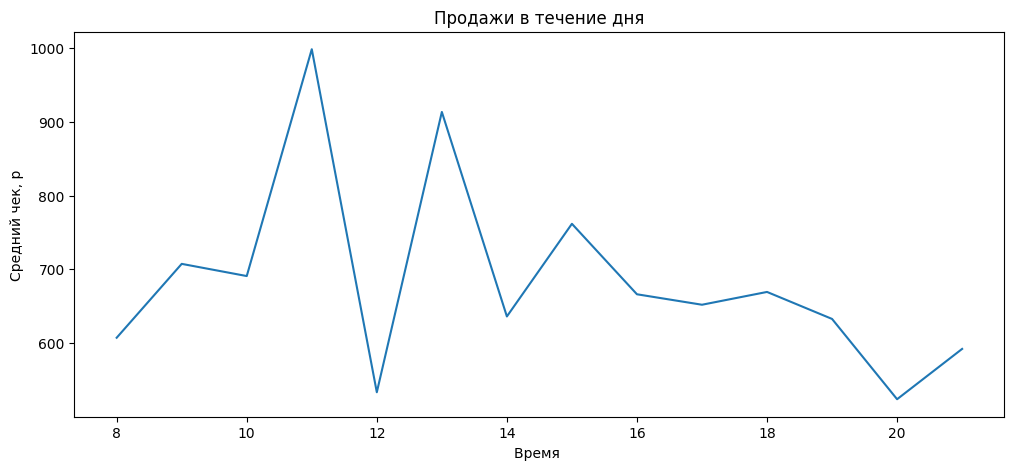

In [935]:
x1 = revenue_hour_of_day['dt']
y1 = revenue_hour_of_day['revenue'] / revenue_hour_of_day['c_orders']

plt.figure(figsize=(12, 5))

plt.plot(x1, y1)

plt.xlabel('Время ')
plt.ylabel('Средний чек, р')
plt.title('Продажи в течение дня')

plt.show()

In [1068]:
# Из двух последних графиков мы видим, что утром меньше продаж ,но выше средний чек, а к вечеру средний чек меньше но выше к-во продаж.


In [1069]:
# Далее посмотрим какие товары в какое время больше всего продаются


In [936]:
df['hour'] = df['dt'].dt.hour

In [940]:
hour_products = (
    df.groupby(['hour', 'name'])
        .agg(revenue = ('revenue', 'sum'),
             quantity = ('quantity', 'sum') )
).reset_index()
hour_products

,hour,name,revenue,quantity
0,8,1Л МАСЛО ПОДСОЛНЕЧНОЕ ОЛЕЙНА,180.0,1.000
1,8,БЕРН 0.449л X 12 ЖБ,125.0,1.000
2,8,Баранина мякоть,1690.0,1.352
3,8,Кола от Мартина Классическая ПЭТ сильногаз. б/...,150.0,1.000
4,8,Мороженое пломбир ванильный с шоколадной крошкой,90.0,1.000
...,...,...,...,...
1020,21,Соус белый,200.0,1.000
1021,21,Соус красный,600.0,3.000
1022,21,Фруктовый лёд Мохито FRUITING,20.0,1.000
1023,21,Хлеб Матнакаш,60.0,1.000


In [948]:
hour_products = hour_products.sort_values(['hour', 'revenue',], ascending = [True, False]).groupby('hour').head(1).reset_index(drop = True)
hour_products

,hour,name,revenue,quantity
0,8,Баранина мякоть,1690.000,1.352
1,9,Говядина шейный антрекот,2352.000,2.940
2,10,Свинина мякоть шашлык,2825.472,3.328
3,11,Свинина шейка маринов.,7309.500,9.746
4,12,Курица филе фермерское,5659.100,11.122
5,13,Шашлык в лаваше,9300.000,31.000
6,14,Шашлык в лаваше,5700.000,19.000
7,15,Шашлык в лаваше куриный,5040.000,18.000
8,16,Люля курин.,4900.000,25.000
9,17,Свинина ребра,5066.160,11.514


СИСТЕМА ЛОЯЛЬНОСТИ И СКИДКИ


In [876]:
df['discount'].describe() # Как мы видим заказчик пока не ввел систему лояльности


count    2038.000000
mean        0.201726
std         3.336344
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        99.000000
Name: discount, dtype: float64

In [880]:
df['discount'].value_counts().sort_index().head(1)

discount
0.0    2021
Name: count, dtype: int64

СОВМЕСТНЫЕ ТОВАРЫ/ТОВАРНЫЕ ПАРЫ


In [881]:
order_positions = df[['order_id', 'name', 'code' ]].drop_duplicates() # Удаляем полностью идентичные строки ,
                                                                      # чтобы не было пар с однинаковыми товарами

In [882]:
positions_by_order = (
    order_positions.groupby('order_id')['code'].
        apply(list)
    
)
positions_by_order

order_id
000e9409-986c-11f1-0a80-1b3900330baf                                        [ЦБ-00015831]
00483bae-971c-11f1-0a80-0698001bb996    [00150, 5998304241167, 5998304241172, 59983042...
0059c996-90db-11f1-0a80-1b8e000f6bff                                              [00120]
00a2b4fc-8b53-11f1-0a80-0592000c3a7d                                        [ЦБ-00019750]
00b7cb06-8b4c-11f1-0a80-019b000bbd65                                        [ЦБ-00017263]
                                                              ...                        
d27d001a-8f38-11f1-0a80-15f000475fb0                                        [ЦБ-00015397]
d28bb558-997c-11f1-0a80-069b0070514e    [5998304241186, 5998304241171, 5998304241211, ...
d2d3c22c-97b6-11f1-0a80-069b000d0a68                                        [ЦБ-00015414]
d33638cb-98a2-11f1-0a80-0cb9004570ea                 [00033, 00115, 00154, 5998304241174]
d33ae0be-9261-11f1-0a80-1444000ddb6a                                      [5998304241157]
N

In [1080]:
# Создадим список пар товаров встречающихся в одном чеке, и посчитаем их
pairs = []
for i in positions_by_order:
    pairs.extend((list(combinations(i, 2))))
count_pairs = Counter(pairs)


In [892]:
df_pair = pd.DataFrame(count_pairs.items(), columns = ['pairs' , 'count']) # Считаем сколько раз встречается каждая пара
df_top_pairs = df_pair.sort_values('count', ascending = False).head(20).reset_index(drop = True)
df_top_pairs

,pairs,count
0,"(5998304241156, 5998304241181)",24
1,"(5998304241167, 5998304241174)",16
2,"(5998304241157, 5998304241181)",15
3,"(5998304241171, 5998304241170)",13
4,"(5998304241181, 5998304241174)",12
5,"(5998304241157, 5998304241156)",11
6,"(5998304241172, 5998304241174)",11
7,"(5998304241171, 5998304241174)",11
8,"(5998304241176, 5998304241156)",10
9,"(5998304241176, 5998304241170)",10


In [893]:
df_top_pairs[['code1', 'code2']] = pd.DataFrame(df_top_pairs['pairs'].tolist()) # Создаем датафрейм где у нас в 2 столбца коды товаров


In [894]:
# Присоединим название продуктов по их коду
products = df[['name', 'code']].drop_duplicates()

In [895]:
df_top_pairs = df_top_pairs.merge(
    products,
    left_on  = 'code1',
    right_on = 'code',
    how = 'left').merge(
    products,
    left_on  = 'code2',
    right_on = 'code',
    how = 'left',
    )


In [896]:
df_top_pairs

,pairs,count,code1,code2,name_x,code_x,name_y,code_y
0,"(5998304241156, 5998304241181)",24,5998304241156,5998304241181,Прожарка 1 кг мяса,5998304241156,Тара большая,5998304241181
1,"(5998304241167, 5998304241174)",16,5998304241167,5998304241174,Хлеб Матнакаш,5998304241167,Пакет с ручками большой,5998304241174
2,"(5998304241157, 5998304241181)",15,5998304241157,5998304241181,Люля курин.,5998304241157,Тара большая,5998304241181
3,"(5998304241171, 5998304241170)",13,5998304241171,5998304241170,Соус белый,5998304241171,Соус красный,5998304241170
4,"(5998304241181, 5998304241174)",12,5998304241181,5998304241174,Тара большая,5998304241181,Пакет с ручками большой,5998304241174
5,"(5998304241157, 5998304241156)",11,5998304241157,5998304241156,Люля курин.,5998304241157,Прожарка 1 кг мяса,5998304241156
6,"(5998304241172, 5998304241174)",11,5998304241172,5998304241174,Лаваш Армянский,5998304241172,Пакет с ручками большой,5998304241174
7,"(5998304241171, 5998304241174)",11,5998304241171,5998304241174,Соус белый,5998304241171,Пакет с ручками большой,5998304241174
8,"(5998304241176, 5998304241156)",10,5998304241176,5998304241156,Свинина мякоть маринов.,5998304241176,Прожарка 1 кг мяса,5998304241156
9,"(5998304241176, 5998304241170)",10,5998304241176,5998304241170,Свинина мякоть маринов.,5998304241176,Соус красный,5998304241170


In [897]:
df_top_pairs = df_top_pairs[['name_x', 'name_y', 'count']]

In [898]:
df_top_pairs = df_top_pairs.rename(columns = {'name_x': 'position № 1', 'name_y': 'position № 2'})

In [899]:
df_top_pairs # Здесь мы видим , что не учтена особенность товарных групп данной розничной точки . 
            # А именно нужно было исключить служебные позиции , оставив основные.

,position № 1,position № 2,count
0,Прожарка 1 кг мяса,Тара большая,24
1,Хлеб Матнакаш,Пакет с ручками большой,16
2,Люля курин.,Тара большая,15
3,Соус белый,Соус красный,13
4,Тара большая,Пакет с ручками большой,12
5,Люля курин.,Прожарка 1 кг мяса,11
6,Лаваш Армянский,Пакет с ручками большой,11
7,Соус белый,Пакет с ручками большой,11
8,Свинина мякоть маринов.,Прожарка 1 кг мяса,10
9,Свинина мякоть маринов.,Соус красный,10


ПРОДЕЛЫВАЕМ ТО ЖЕ САМОЕ НО С ОТЧИЩЕННЫМ ДАТАСЕТОМ

In [900]:
exlude = 'прожарка|тара|пакет'

In [901]:
df_ex = df[~df['name'].str.contains(exlude, case = False, na = False)].drop_duplicates() # Датасет без служебных позиций

In [902]:
order_positions = df_ex.groupby('order_id')['code'].apply(list)

In [903]:
pairs = []
for i in order_positions:
    pairs.extend(list(combinations(i , 2)))
count_pairs = Counter(pairs)

In [904]:
df_pairs = pd.DataFrame(
    count_pairs.items(), columns = ['pairs' , 'count'] ).sort_values(
    'count', ascending = False).head(20).reset_index(drop = True)

In [905]:
df_pairs[['code1', 'code2']] = pd.DataFrame(
    df_pairs['pairs'].tolist())
df_pairs.drop_duplicates()

,pairs,count,code1,code2
0,"(5998304241171, 5998304241170)",13,5998304241171,5998304241170
1,"(5998304241167, 5998304241171)",10,5998304241167,5998304241171
2,"(5998304241176, 5998304241170)",10,5998304241176,5998304241170
3,"(5998304241185, 5998304241167)",9,5998304241185,5998304241167
4,"(5998304241185, 5998304241171)",8,5998304241185,5998304241171
5,"(5998304241172, 5998304241171)",8,5998304241172,5998304241171
6,"(5998304241171, 5998304241167)",8,5998304241171,5998304241167
7,"(5998304241171, 5998304241172)",8,5998304241171,5998304241172
8,"(5998304241157, 5998304241171)",7,5998304241157,5998304241171
9,"(5998304241190, 5998304241188)",7,5998304241190,5998304241188


In [906]:
products_ex = df_ex[['name', 'code']].drop_duplicates()

In [907]:
df_pairs = df_pairs.merge(
    products_ex,
    left_on = 'code1',
    right_on = 'code',
    how = 'left'
).merge(
    products_ex,
    left_on = 'code2',
    right_on = 'code',
    how = 'left')

df_pairs = df_pairs[['name_x', 'name_y', 'count' ]].rename(columns = {'name_x': 'position 1', 'name_y': 'position 2' })

In [908]:
df_pairs

,position 1,position 2,count
0,Соус белый,Соус красный,13
1,Хлеб Матнакаш,Соус белый,10
2,Свинина мякоть маринов.,Соус красный,10
3,Свинина мякоть шашлык,Хлеб Матнакаш,9
4,Свинина мякоть шашлык,Соус белый,8
5,Лаваш Армянский,Соус белый,8
6,Соус белый,Хлеб Матнакаш,8
7,Соус белый,Лаваш Армянский,8
8,Люля курин.,Соус белый,7
9,Шашлык в лаваше куриный,Шашлык в лаваше,7


In [910]:
df_pairs['pairs'] = list(zip(df_pairs['position 1'], df_pairs['position 2' ]))
df_pairs

,position 1,position 2,count,pairs
0,Соус белый,Соус красный,13,"(Соус белый, Соус красный)"
1,Хлеб Матнакаш,Соус белый,10,"(Хлеб Матнакаш, Соус белый)"
2,Свинина мякоть маринов.,Соус красный,10,"(Свинина мякоть маринов., Соус красный)"
3,Свинина мякоть шашлык,Хлеб Матнакаш,9,"(Свинина мякоть шашлык, Хлеб Матнакаш)"
4,Свинина мякоть шашлык,Соус белый,8,"(Свинина мякоть шашлык, Соус белый)"
5,Лаваш Армянский,Соус белый,8,"(Лаваш Армянский, Соус белый)"
6,Соус белый,Хлеб Матнакаш,8,"(Соус белый, Хлеб Матнакаш)"
7,Соус белый,Лаваш Армянский,8,"(Соус белый, Лаваш Армянский)"
8,Люля курин.,Соус белый,7,"(Люля курин., Соус белый)"
9,Шашлык в лаваше куриный,Шашлык в лаваше,7,"(Шашлык в лаваше куриный, Шашлык в лаваше)"


In [911]:
df_top_pairs = df_pairs['pairs']

In [912]:
df_top_pairs.index = range(1 , len(df_top_pairs) + 1)

In [913]:
df_top_pairs

1                     (Соус белый, Соус красный)
2                    (Хлеб Матнакаш, Соус белый)
3        (Свинина мякоть маринов., Соус красный)
4         (Свинина мякоть шашлык, Хлеб Матнакаш)
5            (Свинина мякоть шашлык, Соус белый)
6                  (Лаваш Армянский, Соус белый)
7                    (Соус белый, Хлеб Матнакаш)
8                  (Соус белый, Лаваш Армянский)
9                      (Люля курин., Соус белый)
10    (Шашлык в лаваше куриный, Шашлык в лаваше)
11                   (Фарш говяжий, Фарш свиной)
12              (Хлеб Матнакаш, Лаваш Армянский)
13                (Люля курин., Люля свин/говяж)
14                    (Соус красный, Соус белый)
15            (Свинина шея маринов., Соус белый)
16           (Свинина шея маринов., Люля курин.)
17    (Свинина мякоть маринов., Лаваш Армянский)
18       (Шашлык терияки, Свинина мякоть шашлык)
19             (Свинина мякоть, Лаваш Армянский)
20         (Свинина мякоть маринов., Соус белый)
Name: pairs, dtype: 

ABC - анализ 

In [1041]:
#АВС-анализ товаров по выручке
abc_revenue = df.groupby('name')['revenue'].sum().reset_index().sort_values('revenue', ascending = False)
abc_revenue['share_revenue'] = (abc_revenue['revenue']/(df['revenue'].sum()) * 100).round(2)

In [1043]:
# Сначала посмотрим сколько суммарно вносят в общую долю каждый товар по выручке
abc_revenue['cumulative_share'] = abc_revenue['share_revenue'].cumsum()
abc_revenue

,name,revenue,share_revenue,cumulative_share
252,Шашлык в лаваше,35400.00,5.07,5.07
122,Люля курин.,34060.00,4.88,9.95
253,Шашлык в лаваше куриный,29400.00,4.21,14.16
212,Свинина мякоть маринов.,28424.50,4.07,18.23
218,Свинина шейка маринов.,24945.00,3.57,21.80
...,...,...,...,...
9,1КГ МУКА УВЕЛКА ПШЕНИЧНАЯ ХЛЕБОПЕКАРНАЯ В/С,71.00,0.01,99.97
101,Крем-десерт сливочный с ванилью м.д.ж. 25% 40 г,70.00,0.01,99.98
96,Кости говяжьи,65.04,0.01,99.99
239,"Том.паста Иранская 28% 280г*12 с/б тв ""Донкон...",45.00,0.01,100.00


In [1054]:
abc_revenue['ABC'] = np.select(
    [
        abc_revenue['cumulative_share'] <= 80,
        abc_revenue['cumulative_share'] <= 95,
    ],
    [
        'A', 
        'B'
    ],
    default = 'C'
)

In [1070]:
abc_revenue

,name,revenue,share_revenue,cumulative_share,ABC
252,Шашлык в лаваше,35400.00,5.07,5.07,A
122,Люля курин.,34060.00,4.88,9.95,A
253,Шашлык в лаваше куриный,29400.00,4.21,14.16,A
212,Свинина мякоть маринов.,28424.50,4.07,18.23,A
218,Свинина шейка маринов.,24945.00,3.57,21.80,A
...,...,...,...,...,...
9,1КГ МУКА УВЕЛКА ПШЕНИЧНАЯ ХЛЕБОПЕКАРНАЯ В/С,71.00,0.01,99.97,C
101,Крем-десерт сливочный с ванилью м.д.ж. 25% 40 г,70.00,0.01,99.98,C
96,Кости говяжьи,65.04,0.01,99.99,C
239,"Том.паста Иранская 28% 280г*12 с/б тв ""Донкон...",45.00,0.01,100.00,C


In [1035]:
#АВС - анализ товаров по прибыли
abc_profit = df.groupby('name')['profit'].sum().reset_index().sort_values('profit', ascending = False)
abc_profit['share_profit'] = (abc_profit['profit']/(df['profit'].sum()) * 100).round(2)
abc_profit['cumulative_share'] = abc_profit['share_profit'].cumsum()


,name,profit,share_profit,cumulative_share
105,Курица в ассортменте маринов.,10401.342,5.54,5.54
218,Свинина шейка маринов.,10310.600,5.50,11.04
113,Курица терияки маринов.,9240.250,4.93,15.97
212,Свинина мякоть маринов.,9183.300,4.89,20.86
102,Курица ассорти шашлык,9059.400,4.83,25.69


In [1051]:
abc_profit['ABC'] = np.select(
    [
        abc_profit['cumulative_share'] <= 80,
        abc_profit['cumulative_share'] <= 95,
    ],
    [
        'A', 
        'B'
    ],
    default = 'C'
)
abc_profit

,name,profit,share_profit,cumulative_share,ABC
105,Курица в ассортменте маринов.,10401.342,5.54,5.54,A
218,Свинина шейка маринов.,10310.600,5.50,11.04,A
113,Курица терияки маринов.,9240.250,4.93,15.97,A
212,Свинина мякоть маринов.,9183.300,4.89,20.86,A
102,Курица ассорти шашлык,9059.400,4.83,25.69,A
...,...,...,...,...,...
43,"Аджика Грузинская ЭК 340г*12 с/бут ""Донконсерв...",6.060,0.00,100.05,C
225,Соевый соус Классический 250мл*6 ст/бут Сэнсой,5.820,0.00,100.05,C
239,"Том.паста Иранская 28% 280г*12 с/б тв ""Донкон...",3.800,0.00,100.05,C
207,Свинина антрекот,0.000,0.00,100.05,C


In [1056]:
abc = abc_revenue.merge(
    abc_profit , on = 'name', suffixes=('_revenue', '_profit')

)

In [1060]:
abc_dif = abc[abc['ABC_revenue'] != abc['ABC_profit']]

In [1074]:
abc[abc['ABC_revenue'] == 'A']

,name,revenue,share_revenue,cumulative_share_revenue,ABC_revenue,profit,share_profit,cumulative_share_profit,ABC_profit
0,Шашлык в лаваше,35400.000,5.07,5.07,A,8169.230769,4.35,39.14,A
1,Люля курин.,34060.000,4.88,9.95,A,7204.230769,3.84,42.98,A
2,Шашлык в лаваше куриный,29400.000,4.21,14.16,A,6784.615385,3.62,50.34,A
3,Свинина мякоть маринов.,28424.500,4.07,18.23,A,9183.300000,4.89,20.86,A
4,Свинина шейка маринов.,24945.000,3.57,21.80,A,10310.600000,5.50,11.04,A
5,Курица филе фермерское,24457.790,3.50,25.30,A,434.290000,0.23,89.60,B
6,Свинина шея маринов.,21117.750,3.02,28.32,A,8728.670000,4.65,30.34,A
7,Курица в ассортменте маринов.,20536.742,2.94,31.26,A,10401.342000,5.54,5.54,A
8,Фарш куриный,19978.500,2.86,34.12,A,4610.423077,2.46,52.80,A
9,Свинина ребра,17492.640,2.50,36.62,A,0.000000,0.00,100.05,C


In [1075]:
abc_dif[
    [
        'name',
        'revenue',
        'profit',
        'ABC_revenue',
        'ABC_profit'
    ]
].sort_values(
    ['ABC_revenue', 'ABC_profit', 'profit'],
    ascending=[True, True, False]
)

,name,revenue,profit,ABC_revenue,ABC_profit
38,Тара большая,4770.00,1100.769231,A,B
22,Говядина шейный антрекот,9732.80,1094.940000,A,B
39,Курица крыло,4742.50,1016.250000,A,B
25,Говядина антрекот,8676.80,976.140000,A,B
43,Люля индейки,4200.00,969.230769,A,B
42,Овощи на мангале,4200.00,969.230769,A,B
40,Курица бедро фермерское,4372.90,937.050000,A,B
35,Свинина лопатка без кости,5383.14,549.300000,A,B
5,Курица филе фермерское,24457.79,434.290000,A,B
24,Курица филе домашнее,9187.30,168.300000,A,C


In [1076]:
abc['margin'] = abc['profit'] / abc['revenue'] * 100

abc[
    [
        'name',
        'revenue',
        'profit',
        'margin',
        'ABC_revenue',
        'ABC_profit'
    ]
].sort_values('margin', ascending=False)

,name,revenue,profit,margin,ABC_revenue,ABC_profit
55,Курица крылья шашлык,2209.600,1450.050,65.625000,B,A
13,Курица ассорти шашлык,13804.800,9059.400,65.625000,A,A
53,Вырезка говяжья,2276.000,1468.020,64.500000,B,A
91,Котлеты лососевые POLAR,1050.000,660.000,62.857143,B,B
41,Свинина шея шашлык,4355.298,2560.978,58.801441,A,A
...,...,...,...,...,...,...
5,Курица филе фермерское,24457.790,434.290,1.775671,A,B
45,Говяжья грудинка,4039.200,56.100,1.388889,A,C
46,Ребра говяжьи,3646.080,50.640,1.388889,B,C
32,Свинина антрекот,6143.280,0.000,0.000000,A,C


In [1077]:
kpi = pd.DataFrame({
    'Показатель': [
        'Выручка',
        'Валовая прибыль',
        'Валовая маржинальность, %',
        'Количество чеков',
        'Средний чек',
        'Продано единиц товара',
        'Среднее число позиций в чеке'
    ],
    'Значение': [
        total_revenue,
        gross_profit,
        gross_margin,
        df['order_id'].nunique(),
        average_check,
        total_quantity,
        average_pos_per_check
    ]
})

kpi.round(2)

,Показатель,Значение
0,Выручка,698311.54
1,Валовая прибыль,195147.60
2,"Валовая маржинальность, %",27.95
3,Количество чеков,1000.00
4,Средний чек,698.31
5,Продано единиц товара,2716.30
6,Среднее число позиций в чеке,2.04
